# Overview 

This notebook describes how to do velocity analysis using GRN models. 

### Data
In this notebook, CellOracle uses two input data below for the GRN model construction.

- **Input data1: Oracle object**. 

- **Input data2: Links object**. `Links` object is a class to store GRN data. We need GRN models stored as a `Links` object for simulation.

### What you can do
In this notebook, we perform two analyzes.

1. **Velocity analysis** to simulate cell identity shift. CellOracle uses the GRN model to simulate cell identity shift. For this analysis, you need to construct GRN models in this notebook first.

2. **Compare velocity vector with development vectors**. In order to properly interpret the simulation results, it is very important to consider the natural direction of development. First, I will show you how to get a pseudo-time gradient vector field that represents the direction of development. Then, we compare the CellOracle velocity vector field with the development vector field by calculating the inner product score. See below for more information.
 
### Custom data class / object

In this notebook, CellOracle uses four custom classes, `Oracle`, `Links`, `Gradient_calculator`, and `Oracle_development_module`.

- `Oracle` is the main class in the CellOracle package. It will do almost all calculations of GRN model construction and velocity analysis. 

- `Links` is a class to store GRN data. 

- `Gradient_calculator` calculates development vector field using pseudotime information. We need the pseudotime data for this calculation. 

- `Oracle_development_module` integrates `Oracle` object data and `Gradient_calculator` object data to analyze the correlation between GRNs-based velocity and the developmental process. 


In [39]:
# 0. Import
import os
from re import search
from dfply import *
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

This notebook was made with celloracle version 0.7.0.
Please use celloracle>=0.7.0. Otherwise you may get an error.

In [2]:
import celloracle as co
co.__version__
from celloracle.applications import *

'0.7.5'

In [3]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

# Load settings

In [8]:
if search("ricard", os.uname()[1]):
    exec(open('/Users/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/utils.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/rna_atac/gene_regulatory_networks/GRN/functions/GRN_utils.py').read())
elif search("ebi", os.uname()[1]):
    exec(open('/homes/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/utils.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/rna_atac/gene_regulatory_networks/GRN/functions/GRN_utils.py').read())
elif search("Workstation", os.uname()[1]):
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/settings.py').read())
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/utils.py').read())
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/rna_atac/gene_regulatory_networks/GRN/functions/GRN_utils.py').read())
else:
    exit("Computer not recognised")

## Define I/O

In [9]:
io["outdir"] = io["basedir"] + "/results/rna_atac/GRN/trajectories/blood_trajectory/"

In [10]:
io['blood_chip_oracle'] = io['outdir'] + "/blood_chip.celloracle.oracle"
io['blood_chip_links'] = io['outdir'] + '/blood_chip.celloracle.links'
io['blood_chip_velocity'] = io['outdir'] + '/blood_chip_velocity.celloracle.oracle'

## Define options 

scanpy options

In [11]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(6, 5), facecolor='white')

In [12]:
opts["celltypes"] = [
   "Haematoendothelial_progenitors",
   "Blood_progenitors_1",
   "Blood_progenitors_2",
   "Erythroid1",
   "Erythroid2",
   "Erythroid3"
]

# 1. Load data
## 1.1. Load processed oracle object

Load the oracle object. See the previous notebook for the notes on how to prepare the oracle object.

In [13]:
oracle = co.load_hdf5(io['blood_chip_oracle'])

## 1.2. Load inferred GRNs

In the previous notebook, we calculated GRNs. Now, we will use these GRNs for simulation.
We import GRNs which were saved in the Links object.


In [14]:
# You can load files with the following command.
links = co.load_hdf5(file_path=io['blood_chip_links'])

# 2. Make predictive models for velocity analysis

We will fit ridge regression models again.
This process takes less time than the GRN inference in the previous notebook because we use already filtered GRN models.

In [15]:
links.filter_links()
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)

In [16]:
oracle = fit_GRN_for_simulation(oracle,alpha=10, use_cluster_specific_TFdict=True)

fitting GRN again...
calculating GRN in blood


  0%|          | 0/2064 [00:00<?, ?it/s]

genes_in_gem: 2064
models made for 1035 genes


# 3. Velocity analysis

## 3.1. calculate future gene expression based on GRN

In [17]:
oracle = simulate_future(oracle,GRN_unit='cluster',n_propagation = 1)#n_diff_genes=1500

## 3.3. calculate transition probability between cells

- The steps above simulated global future gene expression shift. This prediction is based on iterative calculations of signal propagation within the GRN. 

- The next step is to calculate the probability of cell state transitions based on the GRNs. You can use the transition probabilities between cells to predict how cells will change given our GRNs

- This transition probability will be used later.


In [18]:
oracle.estimate_transition_prob(n_neighbors=200,
                                knn_random=True,
                                sampled_fraction=1)

# Calculate embedding
oracle.calculate_embedding_shift(sigma_corr = 0.05)

# 4. Visualization
## 4.1. Quiver plot: Show the direction of cell transition at single cell resolution

### Caution: It is very important to find optimal `scale` parameter.

- We need to adjust the `scale` parameter. Please seek to find the optimal  `scale` parameter that provides good visualization.

- If you don't see any vector, you can try the smaller `scale` parameter to magnify vector length. However, if you see large vectors in the right panel, which is a randomized simulation, it means that the scale parameters are too small.


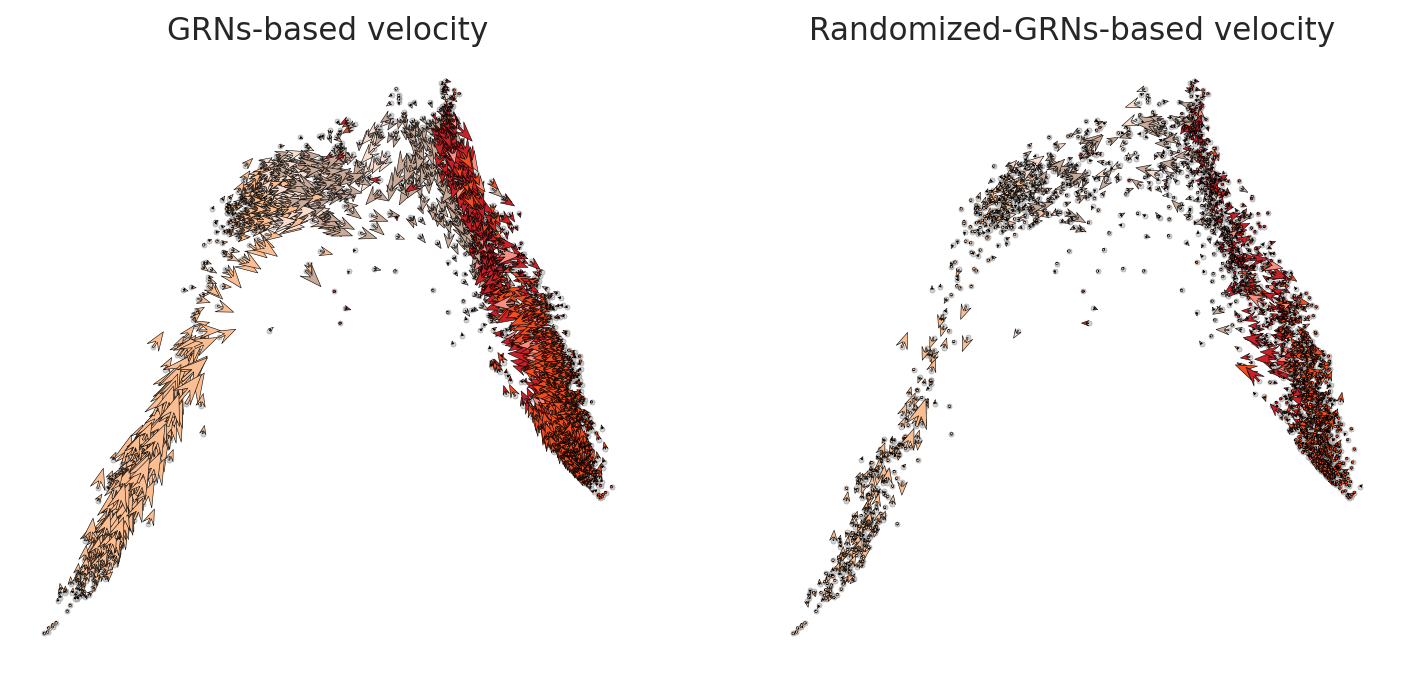

In [19]:
fig, ax = plt.subplots(1, 2,  figsize=[11, 5])
# Select the color column
oracle = set_color(oracle,color='celltype.mapped')

scale = 25
# Show quiver plot
oracle.plot_quiver(scale=scale, ax=ax[0])
ax[0].set_title(f"GRNs-based velocity")

# Show quiver plot that was calculated with randomized GRN.
oracle.plot_quiver_random(scale=scale, ax=ax[1])
ax[1].set_title(f"Randomized-GRNs-based velocity ")

plt.show()

## 4.2. Vector field graph

We can visualize the velocity as a vector field graph. Single cell transition vectors are grouped by grid point.

### 4.2.1  Find parameters for n_grid and min_mass
`n_grid`: Number of grid point.

`min_mass`: Threshold value for the cell density
The appropriate values for these parameters depends on the data. Please find appropriate values as follows.
 


In [20]:
# n_grid = 40 is a good point to start with.
n_grid = 40
oracle.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)

Please run `oracle.suggest_mass_thresholds()`to find appropriate `min_mass` parameter.
It will give you some examples.

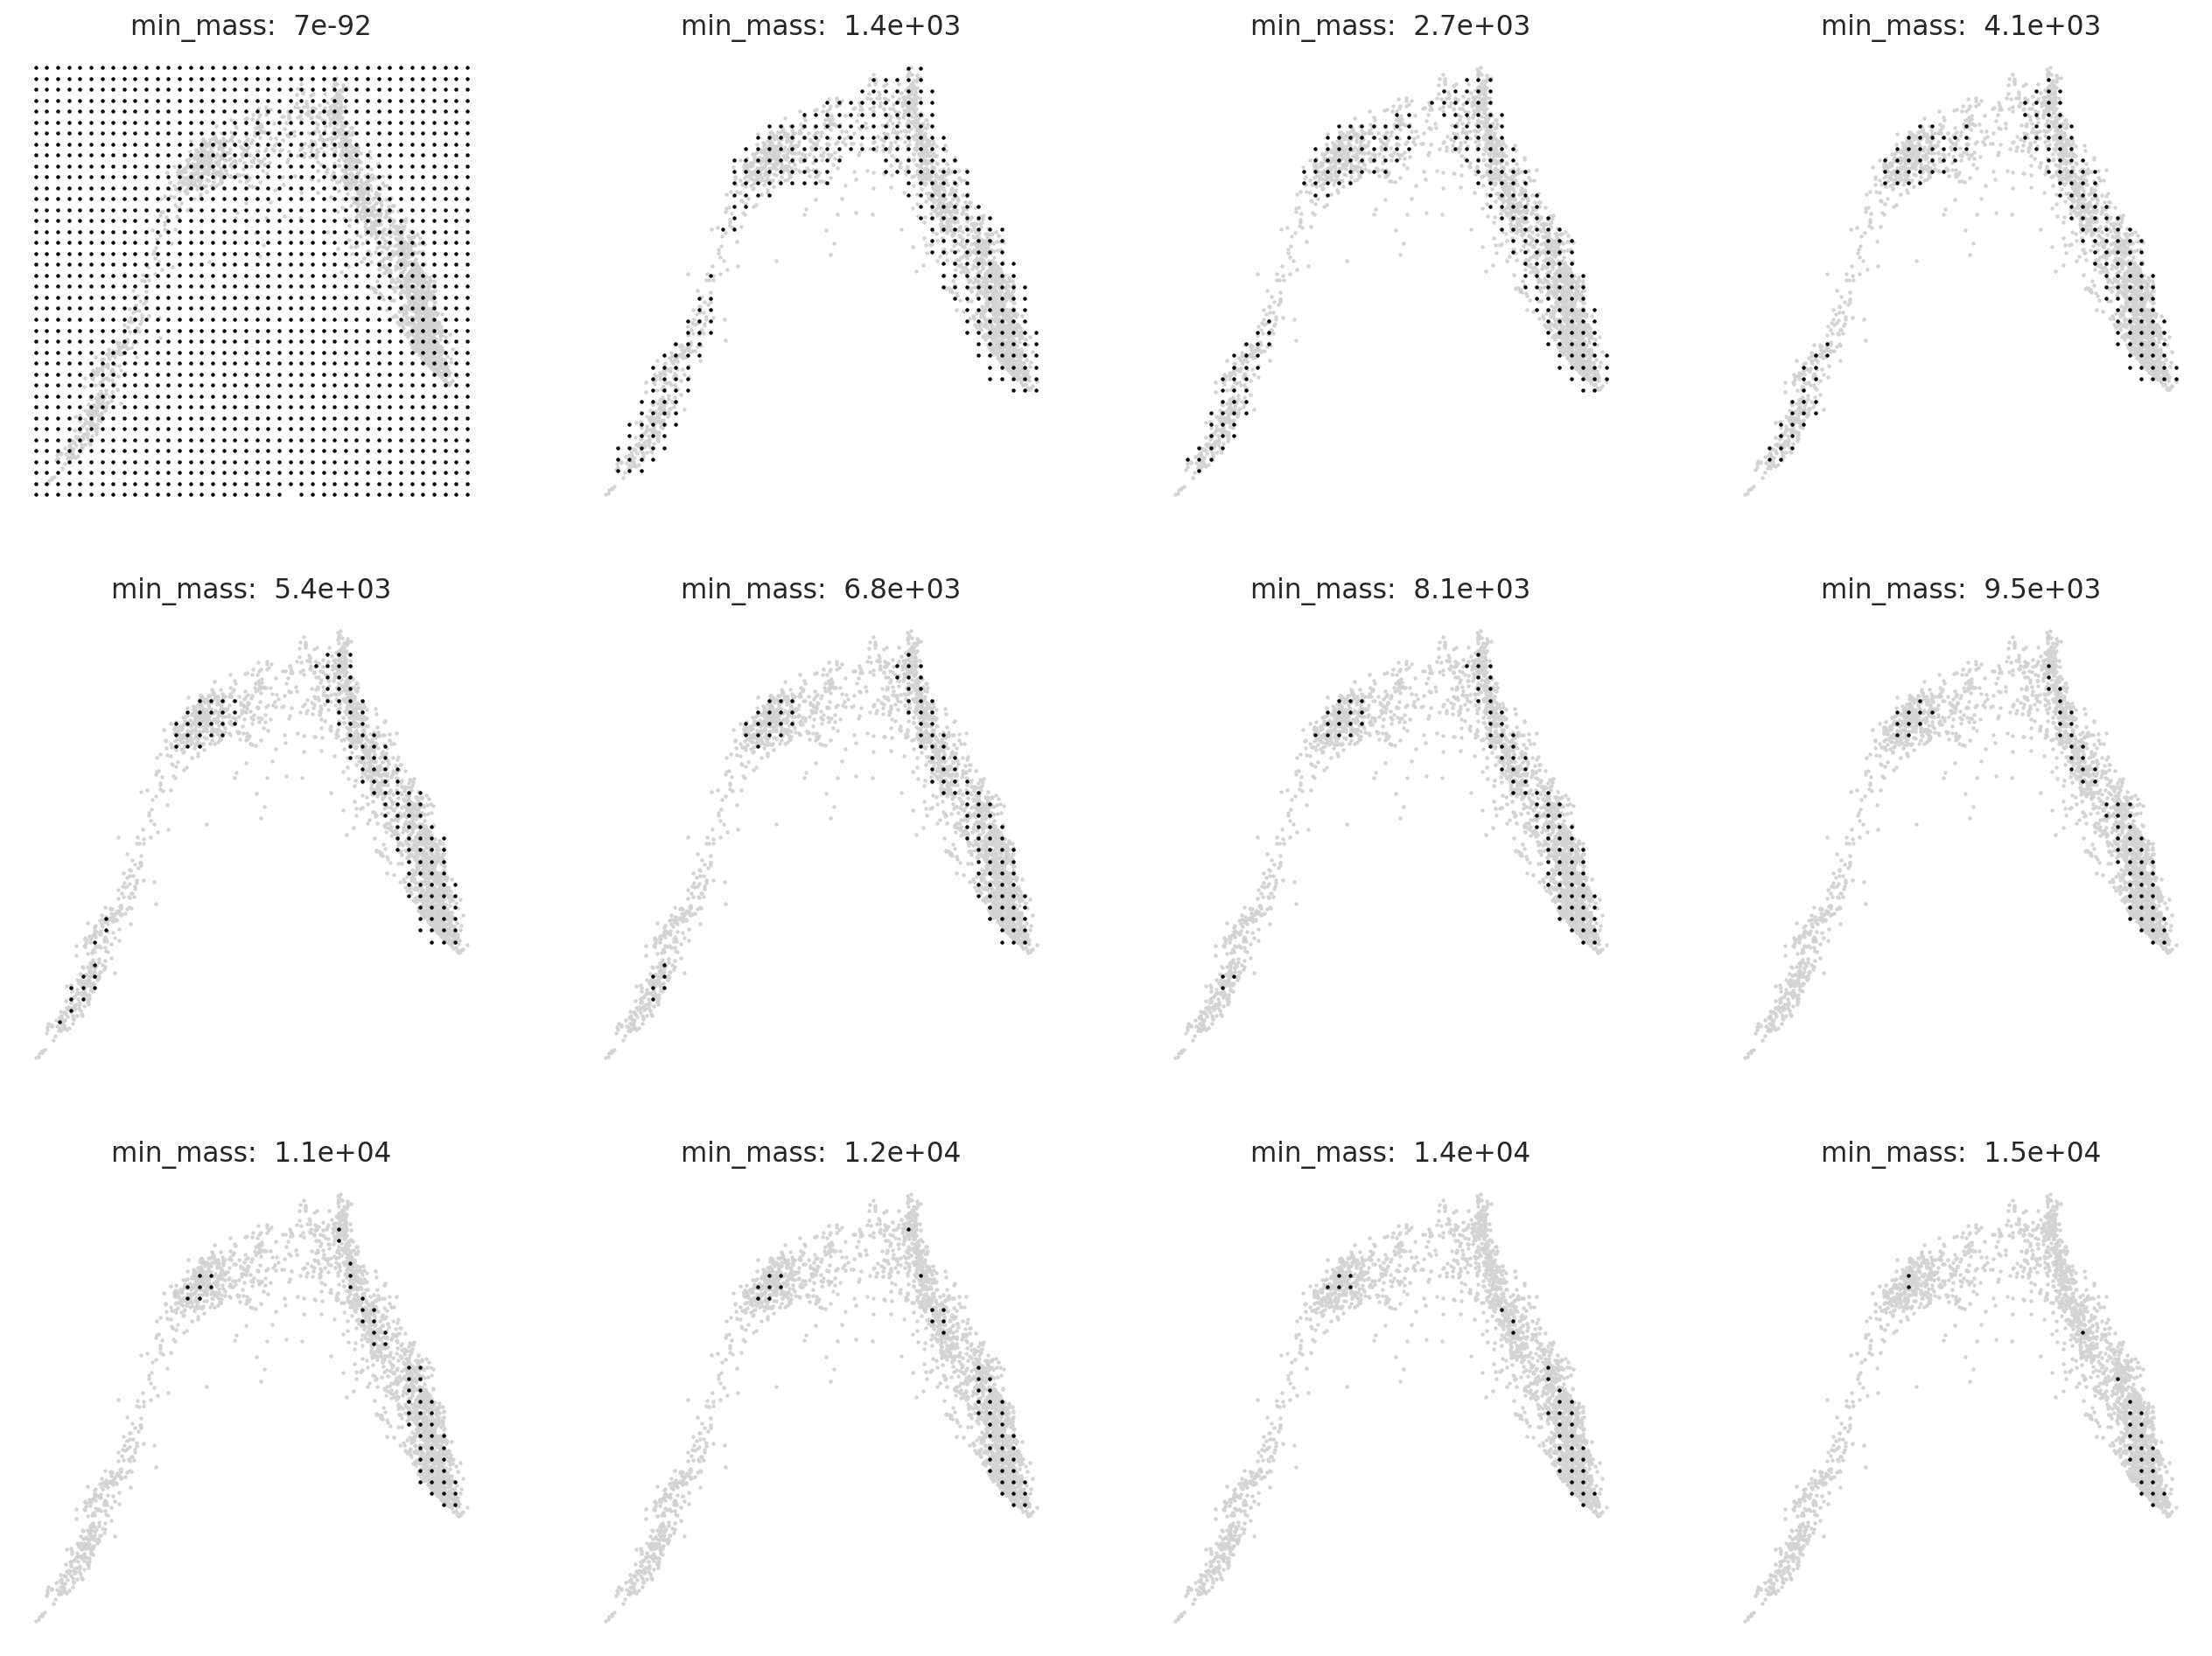

In [21]:
# Search for best min_mass.
oracle.suggest_mass_thresholds(n_suggestion=12)

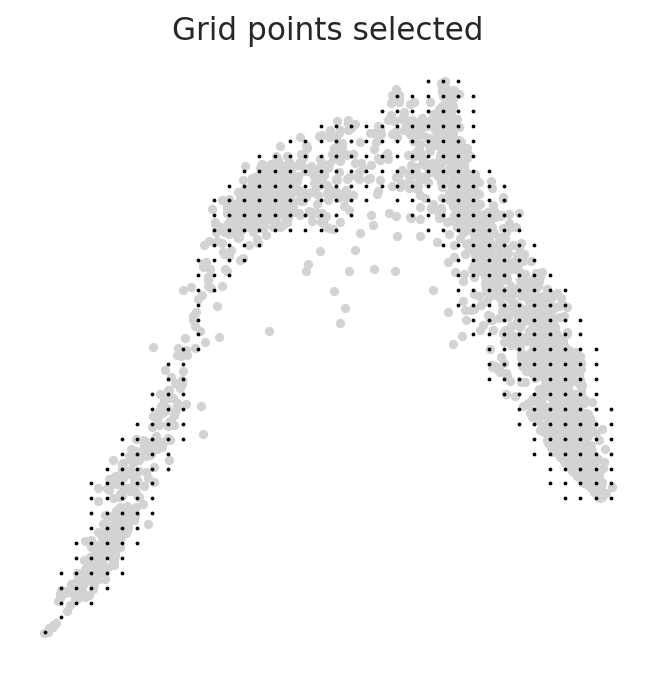

In [22]:
min_mass = 1e3
oracle.calculate_mass_filter(min_mass=min_mass, plot=True)

### 4.2.2  Plot vector fields

- Again, we need to adjust the `scale` parameter. Please seek to find the optimal `scale` parameter that provides good visualization.

- If you don't see any vector, you can try the smaller `scale` parameter to magnify vector length. However, if you see large vectors in the right panel, which is a randomized simulation, it means that the scale parameters are too small.



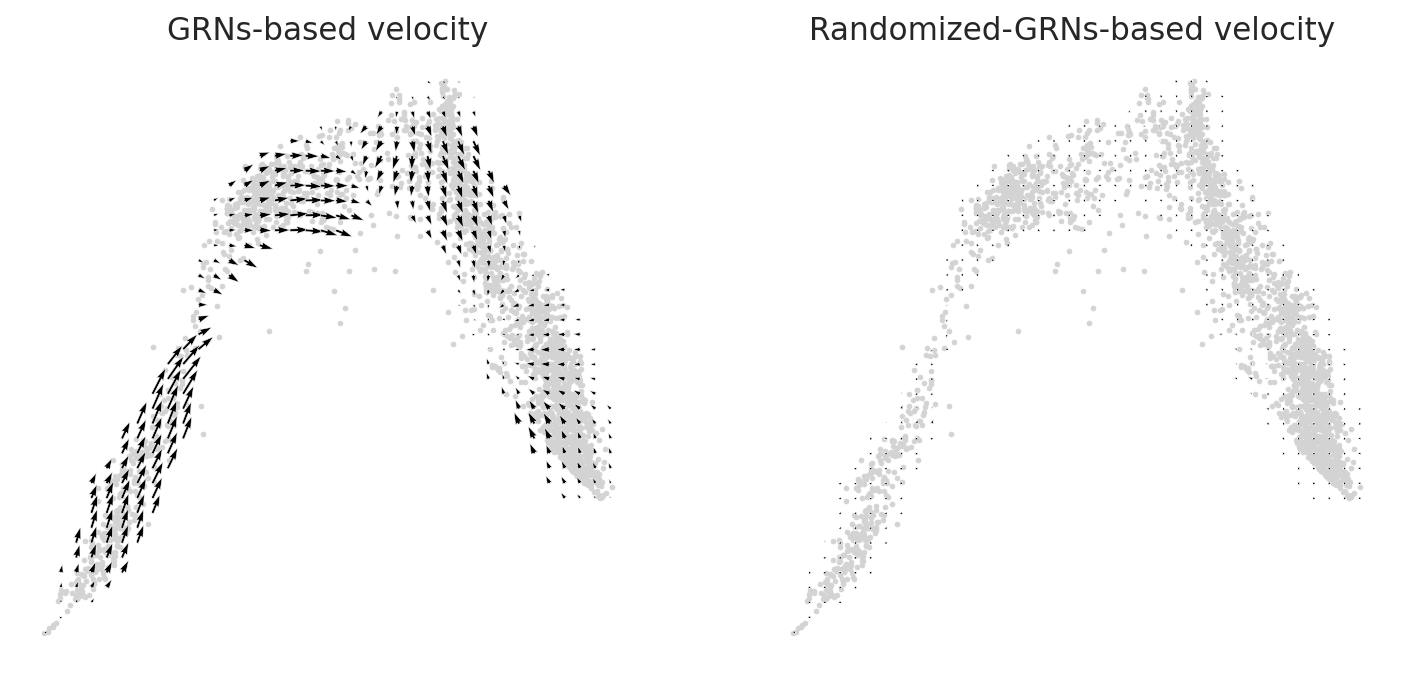

In [23]:
fig, ax = plt.subplots(1, 2,  figsize=[11, 5])

scale_simulation = 25

# Show quiver plot
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax[0])
ax[0].set_title(f"GRNs-based velocity")

# Show quiver plot that was calculated with randomized GRN.
oracle.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1])
ax[1].set_title(f"Randomized-GRNs-based velocity ")

plt.show()

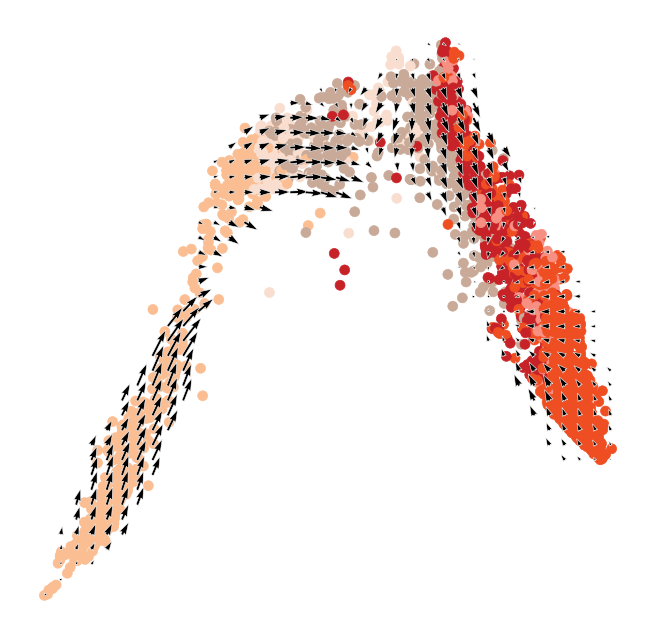

In [24]:
fig, ax = plt.subplots(figsize=[5, 5])
plot_cluster(oracle,ax=ax, s=20,color='celltype.mapped')
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax, show_background=False)

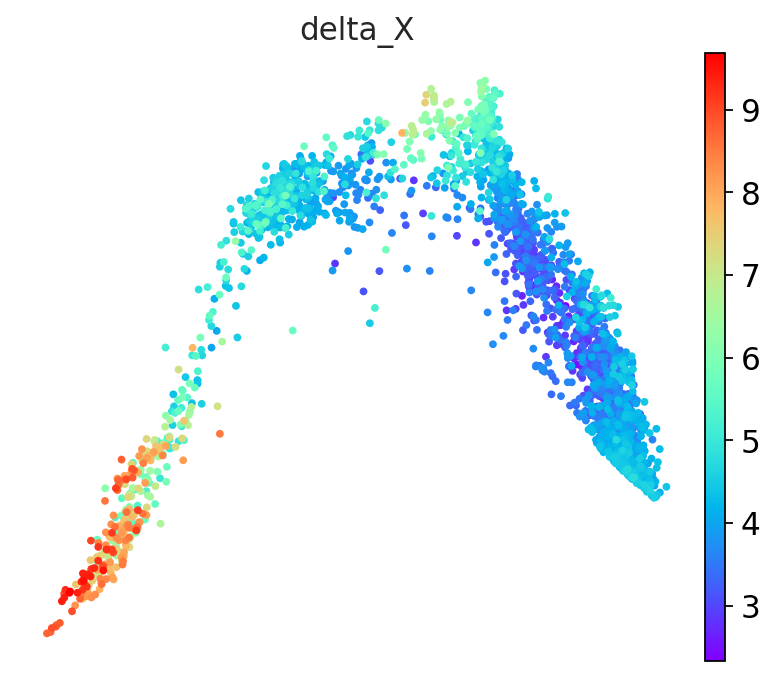

In [25]:
oracle.adata.obs['delta_X'] = np.linalg.norm(oracle.adata.layers["delta_X"], axis=1)
sc.pl.diffmap(oracle.adata,color=['delta_X'], cmap="rainbow")

In [109]:
oracle.to_hdf5(io['blood_chip_velocity'])

# 5. Compare velocity vector with development vectors


## 5.0. Method overview

- As shown above, we can use celloracle's GRNs to infer cell identity transition. The velocity are provided in the form of a vector field map.

- To interpret the results, it is necessary to take into account the direction of natural differentiation. We will compare the velocity vectors with the development vector. 

- Here, we show an example to calculate the vector field of development using **pseudotime gradient**. In short, the process is as follows.
 
 1. Transfer **pseudotime data** into n x n grid point.

 2. Calculate the 2D gradient of pseudotime to get vector field

 3. Compare velocity vector field with development vector field by calculating inner product between these two vectors.

## 5.1. Check data

We use pseudotime data for an input of this analysis.Please calculate continuous pseudotime in advance. 

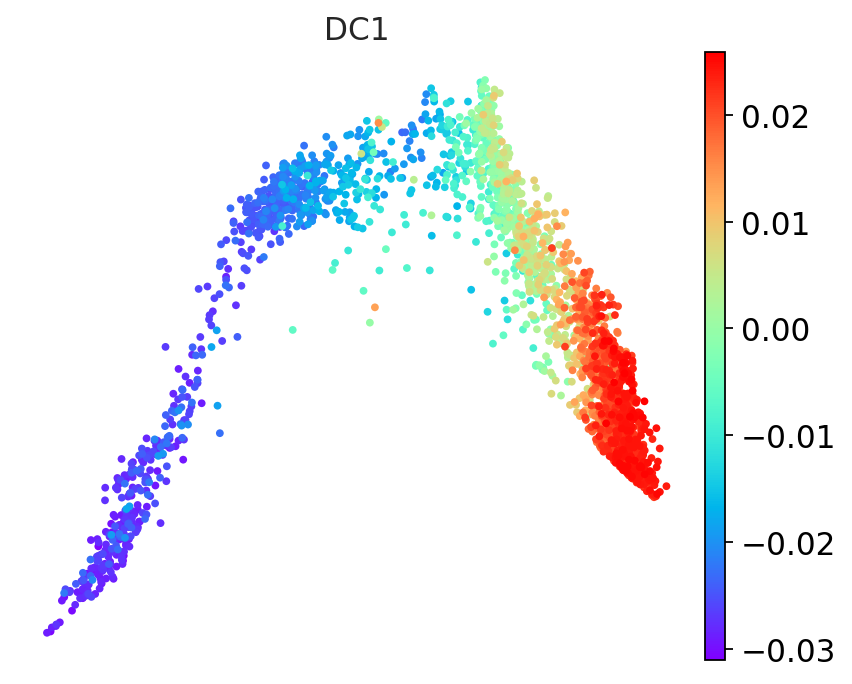

In [26]:
# Visualize pseudotime
fig, ax = plt.subplots(figsize=[6,5])
sc.pl.embedding(adata=oracle.adata, basis=oracle.embedding_name, ax=ax, cmap="rainbow",
                color=["DC1"])

## 5.2. Make Gradient_calculator object

In [27]:
# Instantiate Gradient calculator object
gradient = Gradient_calculator(oracle_object=oracle, pseudotime_key="DC1")

We need to select `n_grid` and `min_mass` to make grid point.
`n_grid`: Number of grid point.

We already know approproate values for them. Please set the same values as step 4.2.1 above.


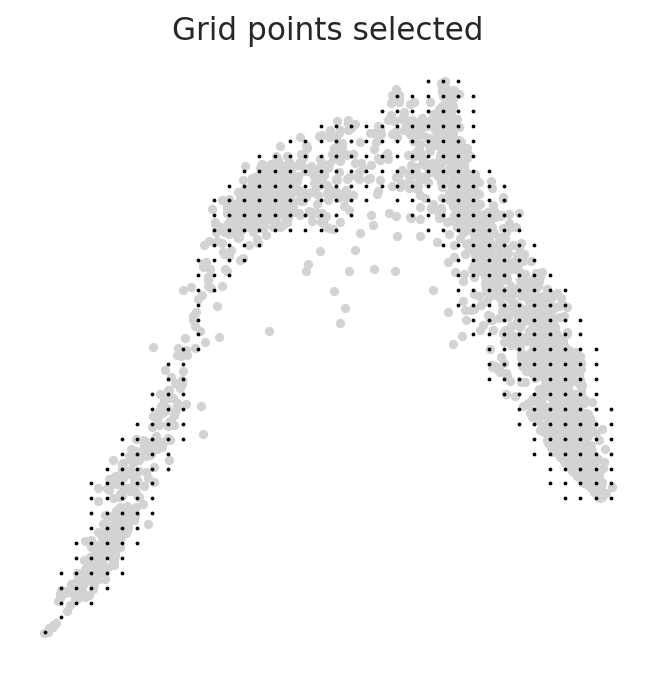

In [28]:
gradient.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)
gradient.calculate_mass_filter(min_mass=min_mass, plot=True)

## 5.4 Transfer pseudotime values to the grid points.

Next, we will transfer pseudotime data into grid points. For this calculation we can chose two method.

- knn: K-Nearesr Neighbor regressor. You need to set number of neighbor.
  Please adjust `n_knn` searching for best results.

 `gradient.transfer_data_into_grid(args={"method": "knn", "n_knn":50})`



- polynomial: Polynomial regression using x-axis and y-axis of dimensional reduction space.

 In general, this method will be more robust. Please use this method if k-nn does not work.
 `n_poly` is the number of degree for the polynomial regression model. Please try to find appropriate`n_poly` searching for best results.
 
 `gradient.transfer_data_into_grid(args={"method": "polynomial", "n_poly":3})`

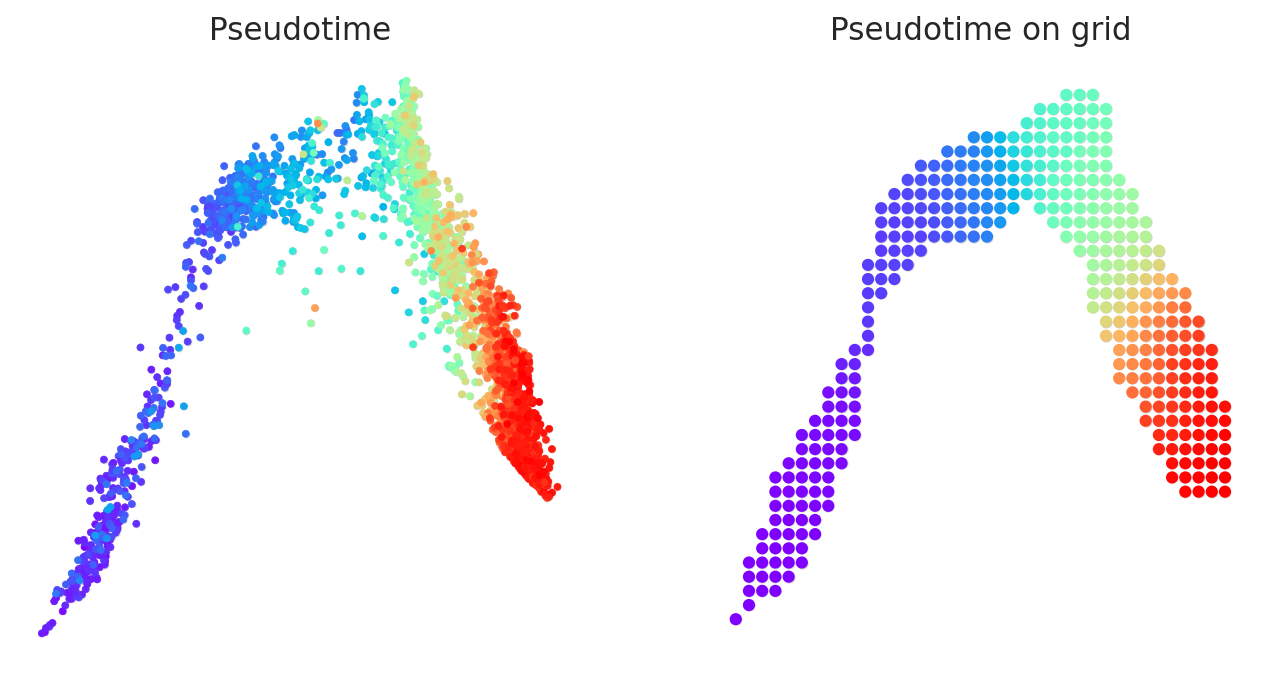

In [29]:
gradient.transfer_data_into_grid(args={"method": "knn", "n_knn":250}, plot=True)

## 5.5. Calculate Gradient vectors

Calculate 2D vector map that represents the gradient of pseudotime. After the gradient calculation, the length of the vector will be normalized automatically.

Please adjust `scale` parameter to adjust vector length.

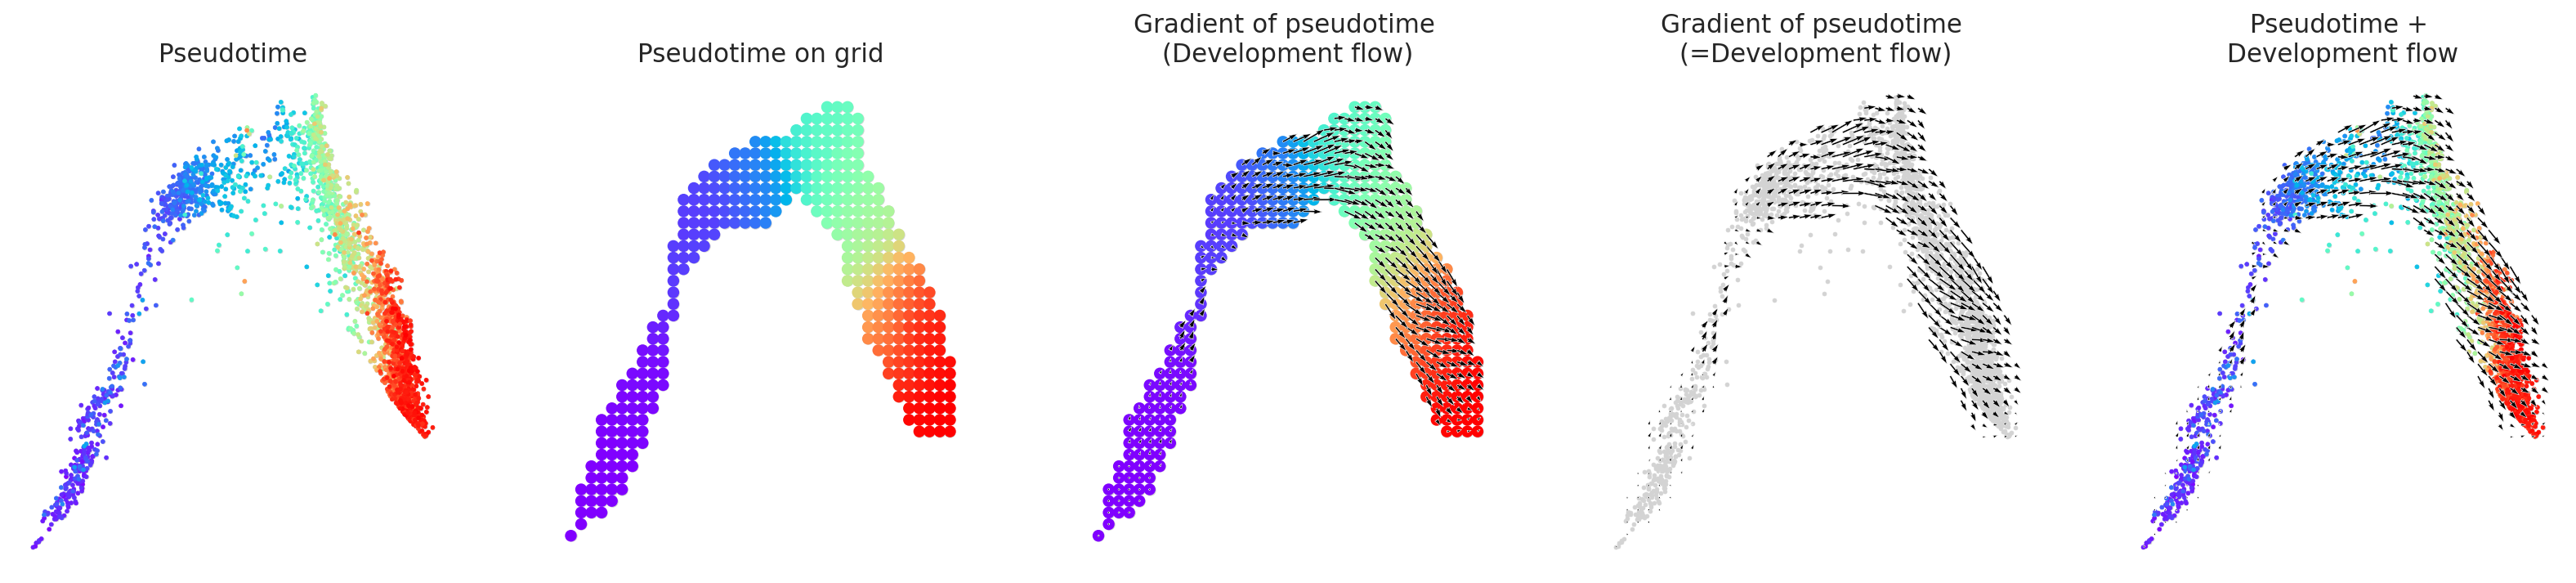

In [30]:
# Calculate graddient
gradient.calculate_gradient()

# Show results
scale_dev = 40
gradient.visualize_results(scale=scale_dev, s=5)

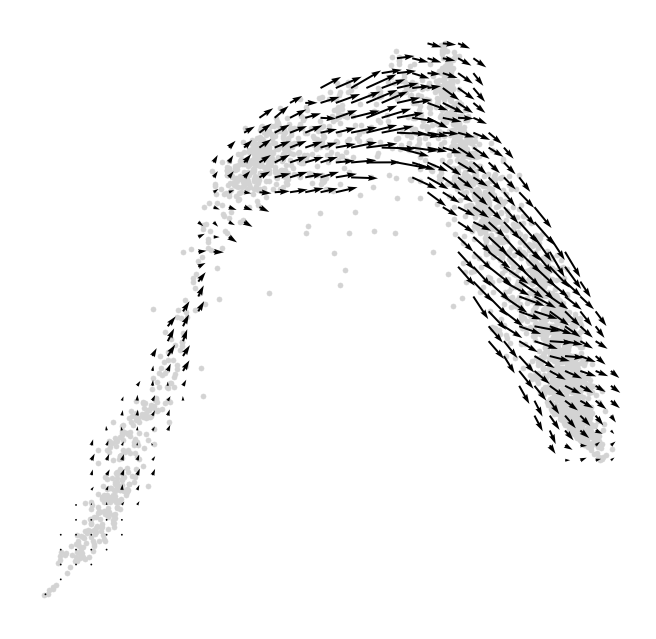

In [31]:
# Visualize results
fig, ax = plt.subplots(figsize=[5, 5])
gradient.plot_dev_flow_on_grid(scale=scale_dev, ax=ax)

## 5.6. Calculate Inner product between two vectors

We will use the inner product to compare the 2D vector map of velocity and development quantitatively.

In [32]:
# Make Oracle_development_module to compare two vector field
dev = Oracle_development_module()

# Load development flow
dev.load_differentiation_reference_data(gradient_object=gradient)

# Load velocity result
dev.load_perturb_simulation_data(oracle_object=oracle)

# Calculate inner produc scores
dev.calculate_inner_product()
dev.calculate_digitized_ip(n_bins=10)

## 5.7 Show results

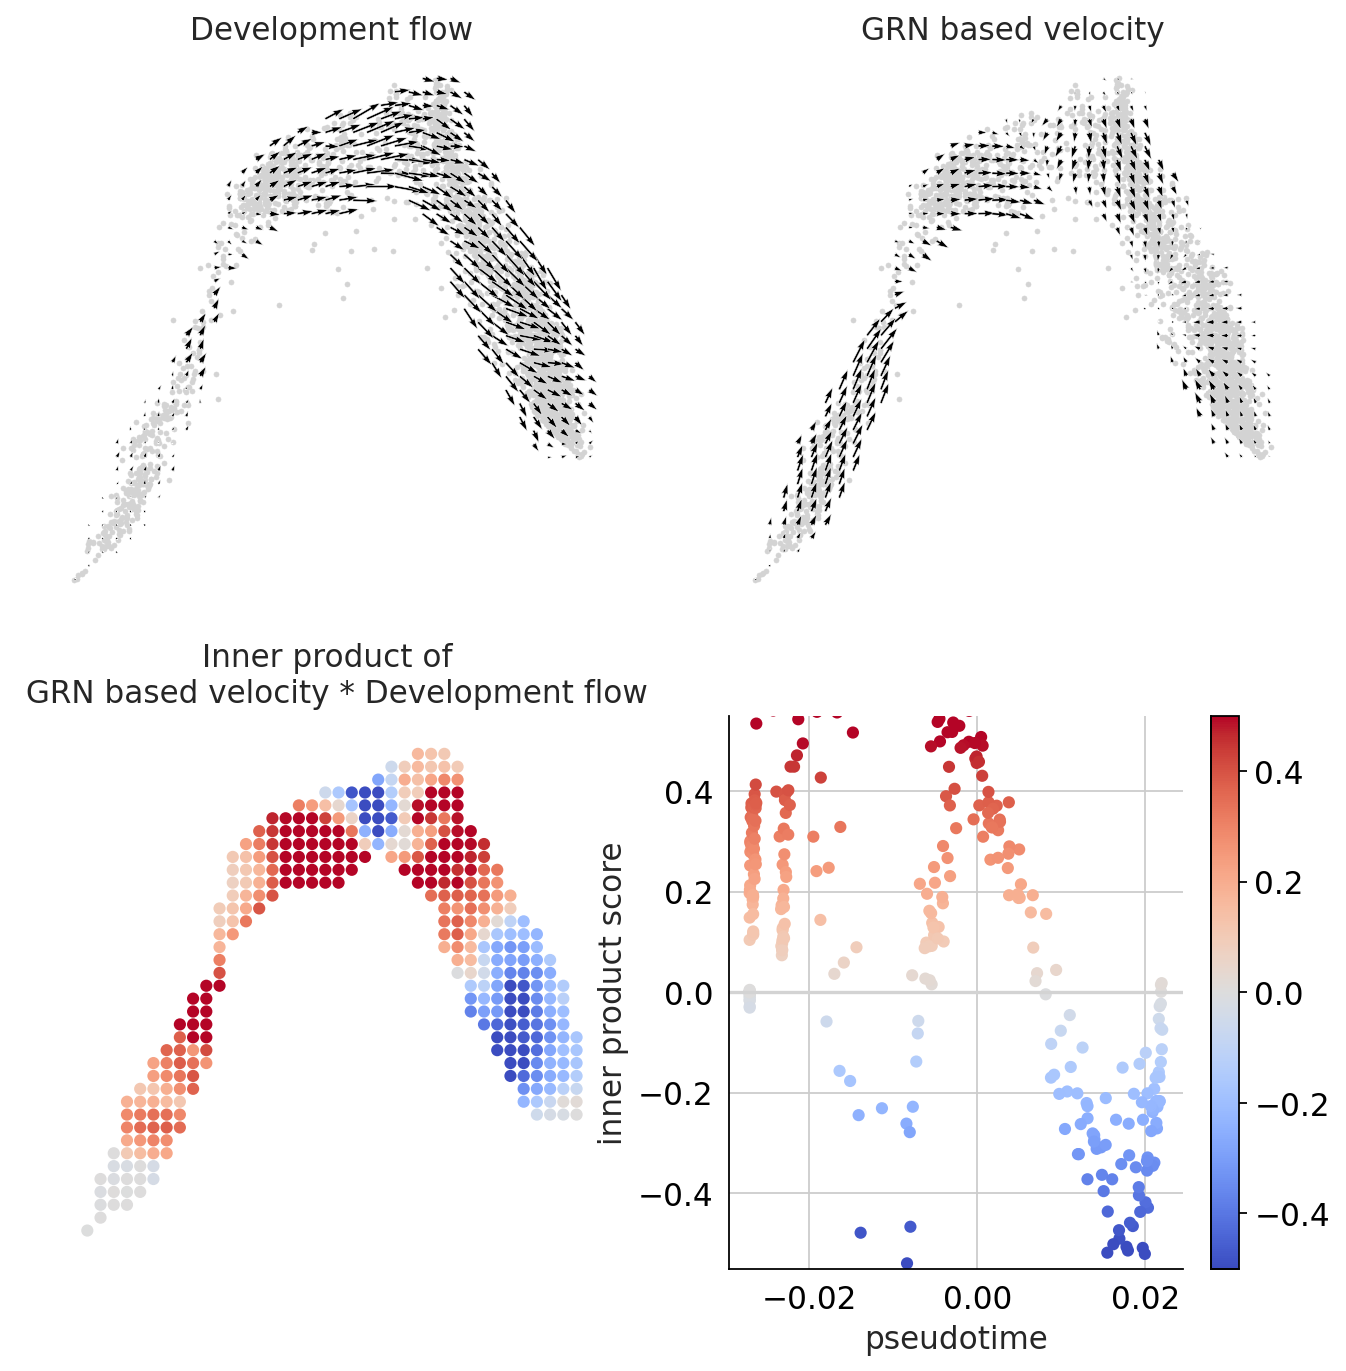

In [33]:
# Let's visualize the results 
visualize_development_module(dev,s=5, 
                                          scale_for_simulation=scale_simulation,
                                          s_grid=20,
                                          scale_for_pseudotime=scale_dev, 
                                          vm=0.5)

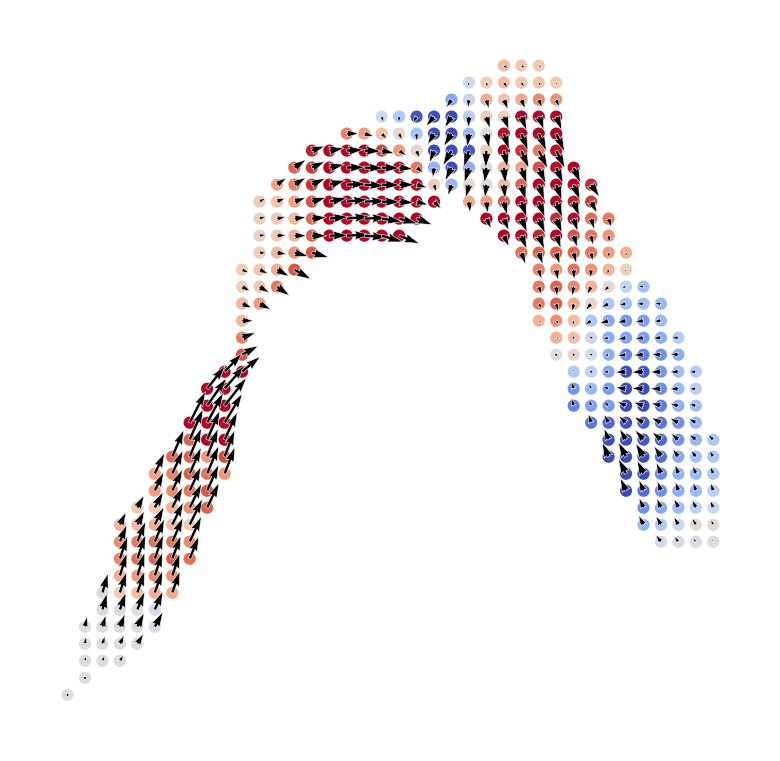

In [34]:
# Show inner product score 
fig, ax = plt.subplots(figsize=[6, 6])
dev.plot_inner_product_on_grid(vm=0.5, s=20, ax=ax)
dev.plot_simulation_flow_on_grid(scale=scale_simulation, show_background=False, ax=ax)

# 6. Focus on a single development lineage to interpret the results in detail

So far, we have used `Oracle_development_module` to analyze the whole cell population.
If you input the index for the cells of interest, Oracle_development_module will analyze subset data.

In [35]:

# Get cell index list for the cells of interest
clusters = ['Erythroid1','Erythroid2','Erythroid3','Blood_progenitors_1','Blood_progenitors_2']
cell_idx = np.where(oracle.adata.obs["celltype.mapped"].isin(clusters))[0]

# Check 
print(cell_idx)

[ 150  209  214 ... 2439 2440 2441]


In [36]:
dev = Oracle_development_module()
# Load development flow

In [37]:
dev.load_differentiation_reference_data(gradient_object=gradient)

# Load simulation result
dev.load_perturb_simulation_data(oracle_object=oracle, 
                                 cell_idx_use=cell_idx, # Enter cell id list
                                 name="Erythroid" # Name of this cell group. You can enter arbitrary name.
                                 )

# Calculate stats
dev.calculate_inner_product()
dev.calculate_digitized_ip(n_bins=10)

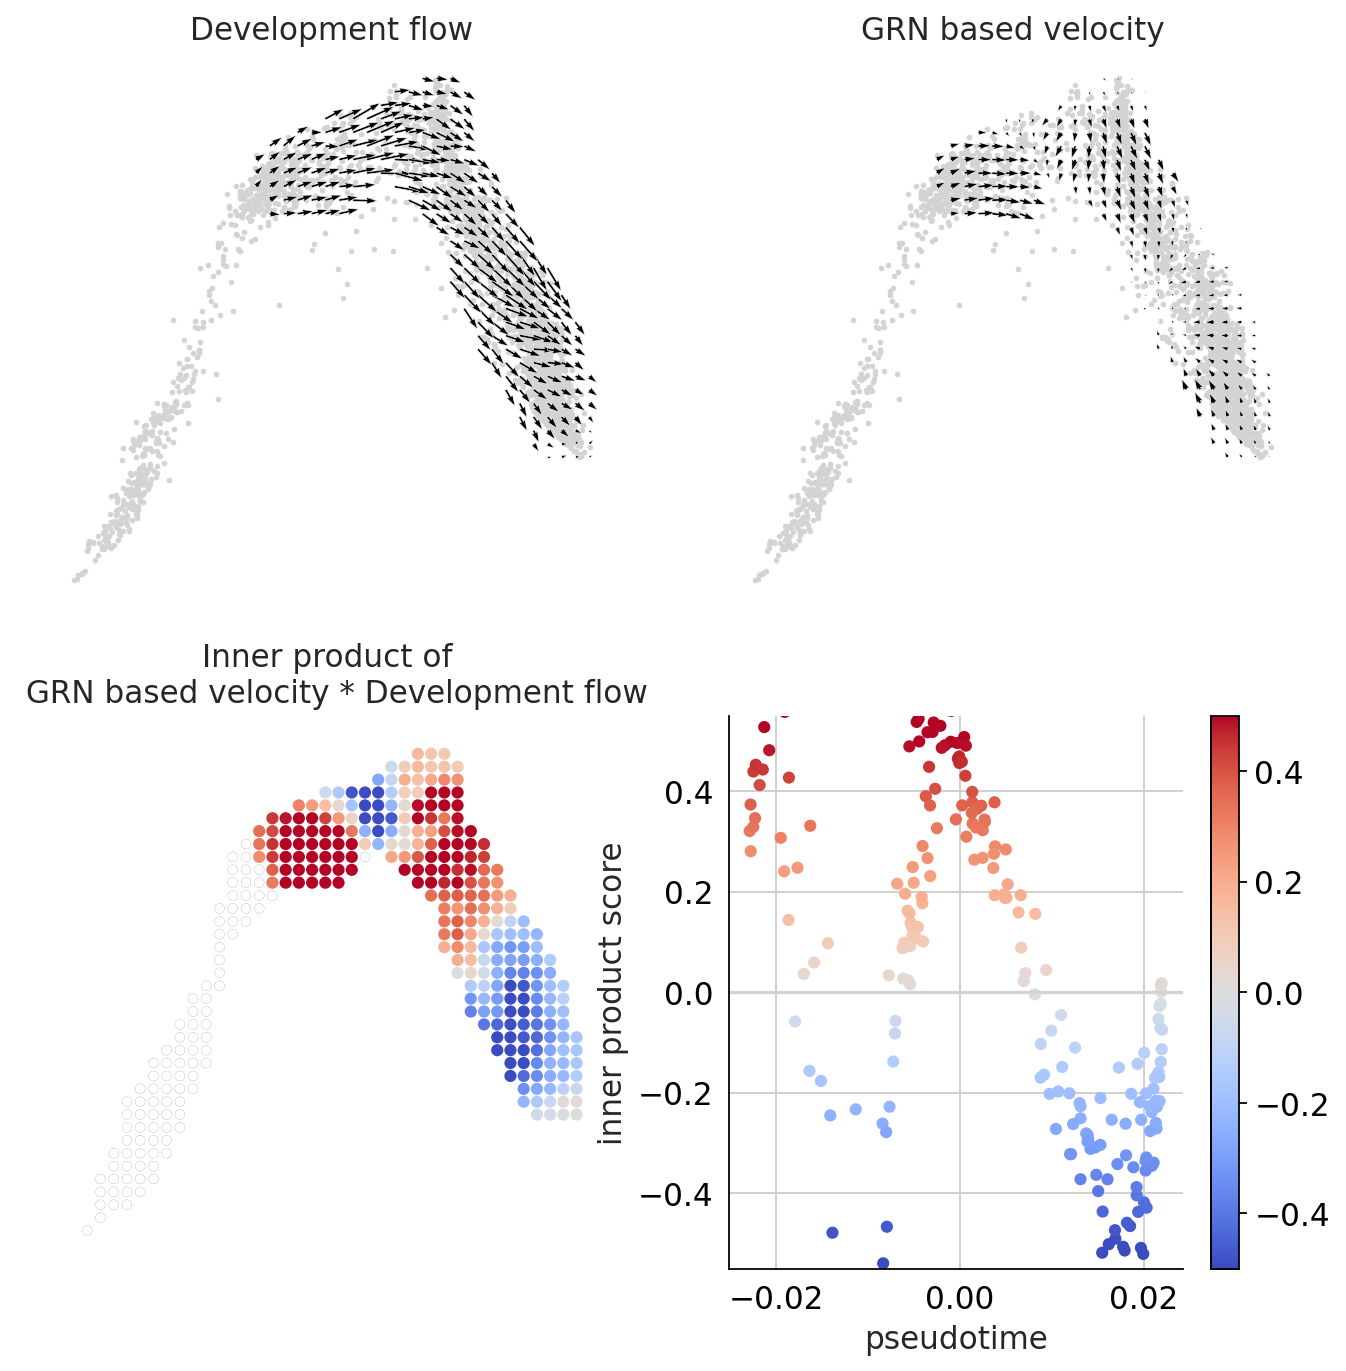

In [38]:
# Let's visualize the results 
visualize_development_module(dev,s=5, 
                              scale_for_simulation=scale_simulation,
                              s_grid=20,
                              scale_for_pseudotime=scale_dev, 
                              vm=0.5)